# SkinCare Recommendation System

## Project Objective
Build an explainable skincare recommendation engine that recommends products from the Skinpro dataset using a user’s skin type, concerns, and preferred product category.

## Recommendation Strategy
The final system uses a hybrid content-based ranking approach combining TF-IDF/cosine similarity with explicit skin-type, concern, and category matching.

## Evaluation Note
The dataset does not contain historical user-item interactions. Evaluation therefore uses synthetic user profiles and attribute-based relevance. Metrics should be interpreted as offline retrieval/ranking quality rather than measured real-user satisfaction.

## Notebook Structure
Data → Cleaning → Feature Engineering → Recommendation Model → Explainability → Evaluation → Test Cases

In [1]:
import pandas as pd
import numpy as np
import re
import ast
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# 1. Dataset Loading & Initial Inspection

Load the Skinpro dataset and inspect its structure, missing values, duplicates, and columns.

In [2]:
df = pd.read_csv("Skinpro - Skinpro (3).csv")

print("Shape:", df.shape)
df.head()

Shape: (214, 5)


,Skin type,Product,Concern,product_url,product_pic
0,Dry,Venusia Max Intensive Moisturizing Cream,"Acne,Hydration",https://dermatics.in/products/venusia-max-intensiv-moisturizing-cream-150gm-for-dry-and-very-dry-skin?variant=42218979492093&currency=INR&utm_medium=product_sync&utm_source=google&utm_content=sag_...,https://dermatics.in/cdn/shop/files/VENUSIA_4-01.webp?v=1694864870&width=823
1,"Oily,Combination",Saslic Foaming Face Wash,Whitehead/Blackhead,https://dermatics.in/products/cipla-saslic-foaming-face-wash-60-ml?variant=40862564909218&currency=INR&utm_medium=product_sync&utm_source=google&utm_content=sag_organic&utm_campaign=sag_organic&ga...,https://dermatics.in/cdn/shop/files/saslic-foam-face-wash.jpg?v=1701779458&width=823
2,Dry,The Derma Co 1% Hyaluronic Sunscreen Aqua Ultra Light Gel with SPF 50 PA++++,Sun protection,https://amzn.to/464QBwM,https://m.media-amazon.com/images/I/51x3cj+-iUL._SL1200_.jpg
3,Dry,Hyalugel,Hydration,https://www.amazon.in/Hyalugel-Hyaluronic-Acid-Gel/dp/B00VNL1IHY,https://thebeautyinsideout.com/wp-content/uploads/2023/12/Hyalugel.webp
4,Normal,Himalaya Neem Face Wash,Pimples,https://himalayawellness.in/products/himalaya-purifying-neem-face-wash,https://himalayawellness.in/cdn/shop/files/100-ml_1800x1800.jpg?v=1705376827


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Skin type    214 non-null    object
 1   Product      214 non-null    object
 2   Concern      214 non-null    object
 3   product_url  213 non-null    object
 4   product_pic  214 non-null    object
dtypes: object(5)
memory usage: 8.5+ KB


In [4]:
df.columns.tolist()

['Skin type', 'Product', 'Concern', 'product_url', 'product_pic']

In [5]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

missing

,Missing Count,Missing %
Skin type,0,0.00
Product,0,0.00
Concern,0,0.00
product_url,1,0.47
product_pic,0,0.00


In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate products:", df["Product"].duplicated().sum())

Duplicate rows: 0
Duplicate products: 0


# 2. Data Cleaning: Column Names

Standardize column names so the rest of the pipeline can reference consistent field names.

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['skin_type', 'product', 'concern', 'product_url', 'product_pic'], dtype='object')

# 3. Exploratory Data Analysis: Skin Type

Inspect the distribution and raw values of skin-type labels.

In [8]:
df["skin_type"].value_counts()

skin_type
Normal,Dry,Combination,Oily,Sensitive        51
Dry                                          27
Oily                                         23
Oily,Combination                             17
Sensitive                                    14
Normal                                       12
Combination                                   7
Dry,Normal                                    6
Normal,Dry                                    5
Normal,Dry,Combination                        5
Dry,Sensitive                                 4
Normal,Combination                            4
Sensitive,Oily                                3
Normal,Dry,Sensitive                          3
Oily,Dry                                      3
Dry                                           3
Normal, Oily, Sensitive, Dry, Combination     2
Normal,Dry,Combination,Oily                   2
Normal,Oily                                   2
Dry,Oily,Normal,Combination,Sensitive         2
Normal,Oily,Dry               

In [9]:
df["skin_type"].unique()

array(['Dry', 'Oily,Combination', 'Normal',
       'Dry,Oily,Normal,Combination,Sensitive', 'Sensitive,Oily', 'Oily',
       'Combination,Oily', 'Sensitive', 'Combination',
       'Normal,Combination', 'Normal,Combination,Oily,Dry,Sensitive',
       'Dry,Sensitive,Combination', 'Normal,Oily', 'Normal,Dry,Sensitive',
       'Dry,Normal', 'Oily,Dry', 'Dry ', 'Dry,Sensitive',
       'Dry,Normal,Oily,Combination', 'Normal,Dry,Combination',
       'Normal,Dry,Combination,Oily,Sensitive',
       'Oily,Sensitive,Combination', 'Sensitive,Combination',
       'Normal,Sensitive', 'Normal,Dry', 'Normal,Dry,Combination,Oily',
       'Normal, Oily, Sensitive, Dry, Combination', 'Dry,Combination',
       'Dry,Normal,Sensitive', 'Dry,Combination,Oily,Sensitive',
       'Dry, Sensitive, Combination', 'Oily,Dry,Sensitive',
       'Normal,Oily,Dry', 'Oily ', 'Dry,Normal,Combination',
       'Sensitive,Dry', 'Combination,Oily,Sensitive'], dtype=object)

# 4. Data Cleaning: Skin Type

Normalize skin-type labels into a consistent vocabulary.

In [10]:
def normalize_skin_type(value):
    if pd.isna(value):
        return "Unknown"
    
    value = str(value).strip().lower()
    
    value = value.replace("-", " ")
    
    if "combination" in value:
        return "Combination"
    elif "oily" in value:
        return "Oily"
    elif "dry" in value:
        return "Dry"
    elif "sensitive" in value:
        return "Sensitive"
    elif "normal" in value:
        return "Normal"
    else:
        return value.title()

In [11]:
df["skin_type_clean"] = df["skin_type"].apply(normalize_skin_type)

In [12]:
df["skin_type_clean"].value_counts()

skin_type_clean
Combination    102
Dry             50
Oily            35
Sensitive       15
Normal          12
Name: count, dtype: int64

# 5. Exploratory Data Analysis: Concerns

Inspect the product concern labels before normalization.

In [13]:
df["concern"].unique()

array(['Acne,Hydration', 'Whitehead/Blackhead', 'Sun protection',
       'Hydration', 'Pimples', 'Pigmentation', 'Hydration,Irritation',
       'Hydration, Irritation', 'Acne', 'Acne,Whitehead/Blackhead',
       'Dark Spots', 'Dark Spots,Pigmentation',
       'Hydration,Broken barrier', 'Hydration,Exfoliation',
       'Whitehead/Blackhead,Exfoliation', 'Acne,Dark Spots',
       'Broken barrier', 'Hydration,Broken barrier,Irritation',
       'Whitehead/Blackhead,Acne', 'Broken barrier,Hydration', 'Pores',
       'Pigmentation,Dark Spots', 'Sun protection,Broken barrier',
       'Exfoliation', 'Pimples,Acne', 'Whitehead/Blackhead,Pores',
       'Acne,Pimples', ' Acne ', 'Irritation,Skin soothing',
       'Pigmentation,Acne', 'Sun protection,Hydration', 'Irritation',
       'Skin soothing,Pores', 'Skin soothing', 'Pores,Skin soothing',
       'Sun protection,Irritation', 'Acne,Whitehead/Blackhead,Pimples',
       'Exfoliation,Hydration', 'Pores,Hydration',
       'Broken barrier,Whitehead

In [14]:
df["concern"].value_counts()

concern
Sun protection                         28
Hydration                              26
Acne                                   23
Pigmentation                           13
Broken barrier                         12
Skin soothing                           9
Pores                                   8
Exfoliation                             7
Hydration,Broken barrier                6
Pigmentation,Dark Spots                 6
Irritation                              5
Pimples                                 4
Dark Spots                              4
Whitehead/Blackhead                     4
Broken barrier,Hydration                4
Hydration,Skin soothing                 3
Pores,Skin soothing                     3
Acne,Hydration                          3
Whitehead/Blackhead,Acne                2
Pigmentation,Acne                       2
Exfoliation,Hydration                   2
Hydration,Irritation                    2
Acne,Pores                              2
Pores,Dark Spots          

# 6. Data Cleaning: Concerns

Split multi-valued concern fields and standardize individual labels.

In [15]:
def clean_concerns(value):
    if pd.isna(value):
        return []
    
    value = str(value).lower().strip()
    
    # Split on common separators
    parts = re.split(r",|/|;|\|", value)
    
    cleaned = []
    
    for part in parts:
        part = part.strip()
        
        if part:
            cleaned.append(part)
    
    return list(set(cleaned))

In [16]:
df["concerns_list"] = df["concern"].apply(clean_concerns)

In [17]:
df[["product", "concern", "concerns_list"]].head(20)

,product,concern,concerns_list
0,Venusia Max Intensive Moisturizing Cream,"Acne,Hydration","[hydration, acne]"
1,Saslic Foaming Face Wash,Whitehead/Blackhead,"[blackhead, whitehead]"
2,The Derma Co 1% Hyaluronic Sunscreen Aqua Ultra Light Gel with SPF 50 PA++++,Sun protection,[sun protection]
3,Hyalugel,Hydration,[hydration]
4,Himalaya Neem Face Wash,Pimples,[pimples]
5,Mamaearth Ubtan Face Wash with Turmeric & Saffron for Tan Removal,Pigmentation,[pigmentation]
6,Kama Ayurveda Pure Rosewater,"Hydration,Irritation","[hydration, irritation]"
7,Simple Kind to Skin Moisturizing Facial Wash,"Hydration, Irritation","[hydration, irritation]"
8,Emolene,Hydration,[hydration]
9,Requil Ceramide and Hyaluronic acid moisturizer,Hydration,[hydration]


# 7. Concern Taxonomy

Map common variations to consistent concern categories such as Dark Spots and Anti-Aging.

In [18]:
def normalize_concern(concern):
    concern = concern.lower().strip()
    
    mappings = {
        "whitehead": "Whiteheads",
        "whiteheads": "Whiteheads",
        "blackhead": "Blackheads",
        "blackheads": "Blackheads",
        "whitehead/blackhead": "Acne",
        "acne": "Acne",
        "hydration": "Hydration",
        "dryness": "Dryness",
        "dark spots": "Dark Spots",
        "darkspot": "Dark Spots",
        "sun protection": "Sun Protection",
        "sun damage": "Sun Protection",
        "anti aging": "Anti-Aging",
        "aging": "Anti-Aging",
        "wrinkles": "Anti-Aging",
        "redness": "Redness",
        "dullness": "Dullness"
    }
    
    return mappings.get(concern, concern.title())

In [19]:
df["concerns_list"] = df["concerns_list"].apply(
    lambda x: list(set(normalize_concern(c) for c in x))
)

In [20]:
df[["product", "concerns_list"]].head(20)

,product,concerns_list
0,Venusia Max Intensive Moisturizing Cream,"[Hydration, Acne]"
1,Saslic Foaming Face Wash,"[Blackheads, Whiteheads]"
2,The Derma Co 1% Hyaluronic Sunscreen Aqua Ultra Light Gel with SPF 50 PA++++,[Sun Protection]
3,Hyalugel,[Hydration]
4,Himalaya Neem Face Wash,[Pimples]
5,Mamaearth Ubtan Face Wash with Turmeric & Saffron for Tan Removal,[Pigmentation]
6,Kama Ayurveda Pure Rosewater,"[Irritation, Hydration]"
7,Simple Kind to Skin Moisturizing Facial Wash,"[Irritation, Hydration]"
8,Emolene,[Hydration]
9,Requil Ceramide and Hyaluronic acid moisturizer,[Hydration]


# 8. Feature Engineering: Product Category

Infer product category from the product name because the source dataset does not provide a dedicated category column.

In [21]:
def extract_category(product_name):
    name = str(product_name).lower()
    
    category_keywords = {
        "Cleanser": [
            "cleanser", "face wash", "facial wash", "cleansing"
        ],
        "Moisturizer": [
            "moisturizer", "moisturiser", "moisturizing",
            "moisturising", "cream", "lotion"
        ],
        "Serum": [
            "serum"
        ],
        "Sunscreen": [
            "sunscreen", "sun screen", "spf"
        ],
        "Face Mask": [
            "mask"
        ],
        "Toner": [
            "toner"
        ],
        "Face Oil": [
            "face oil", "facial oil"
        ],
        "Eye Care": [
            "eye cream", "eye gel", "under eye"
        ]
    }
    
    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in name:
                return category
    
    return "Other"

In [22]:
df["category"] = df["product"].apply(extract_category)

In [23]:
df[["product", "category"]].head(30)

,product,category
0,Venusia Max Intensive Moisturizing Cream,Moisturizer
1,Saslic Foaming Face Wash,Cleanser
2,The Derma Co 1% Hyaluronic Sunscreen Aqua Ultra Light Gel with SPF 50 PA++++,Sunscreen
3,Hyalugel,Other
4,Himalaya Neem Face Wash,Cleanser
5,Mamaearth Ubtan Face Wash with Turmeric & Saffron for Tan Removal,Cleanser
6,Kama Ayurveda Pure Rosewater,Other
7,Simple Kind to Skin Moisturizing Facial Wash,Cleanser
8,Emolene,Other
9,Requil Ceramide and Hyaluronic acid moisturizer,Moisturizer


# 9. Feature Engineering: Product Profiles

Combine skin type, concerns, and category into a text representation for TF-IDF.

In [24]:
df["concerns_text"] = df["concerns_list"].apply(
    lambda x: " ".join(x)
)

In [25]:
df["product_profile"] = (
    "skin_" + df["skin_type_clean"].str.lower().str.replace(" ", "_") + " "
    + "concern_" + df["concerns_text"].str.lower().str.replace(" ", "_") + " "
    + "category_" + df["category"].str.lower().str.replace(" ", "_")
)

In [26]:
df[["product", "product_profile"]].head()

,product,product_profile
0,Venusia Max Intensive Moisturizing Cream,skin_dry concern_hydration_acne category_moisturizer
1,Saslic Foaming Face Wash,skin_combination concern_blackheads_whiteheads category_cleanser
2,The Derma Co 1% Hyaluronic Sunscreen Aqua Ultra Light Gel with SPF 50 PA++++,skin_dry concern_sun_protection category_sunscreen
3,Hyalugel,skin_dry concern_hydration category_other
4,Himalaya Neem Face Wash,skin_normal concern_pimples category_cleanser


# 10. Recommendation Model: TF-IDF

Transform each product profile into a numerical vector representation.

In [27]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

product_vectors = tfidf.fit_transform(
    df["product_profile"]
)

print("Matrix shape:", product_vectors.shape)

Matrix shape: (214, 220)


In [28]:
similarity_matrix = cosine_similarity(product_vectors)

print(similarity_matrix.shape)

(214, 214)


# 11. Item-to-Item Similarity Sanity Check

Check whether the learned representation produces sensible similar-product results.

In [29]:
def similar_products(product_name, top_k=5):
    
    matches = df[
        df["product"].str.lower() == product_name.lower()
    ]
    
    if matches.empty:
        return "Product not found"
    
    idx = matches.index[0]
    
    similarity_scores = similarity_matrix[idx]
    
    similar_indices = np.argsort(similarity_scores)[::-1]
    
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ][:top_k]
    
    results = df.iloc[similar_indices].copy()
    
    results["similarity"] = similarity_scores[similar_indices]
    
    return results[
        ["product", "skin_type_clean", "concerns_list",
         "category", "similarity"]
    ]

In [30]:
df["product"].iloc[0]

'Venusia Max Intensive Moisturizing Cream'

In [31]:
similar_products(df["product"].iloc[0])

,product,skin_type_clean,concerns_list,category,similarity
73,IPCA Acne-OC Sebum Regulating Moisturizer,Oily,"[Hydration, Acne]",Moisturizer,0.610057
143,The Beauty Sailor Coffee Face Wash,Oily,"[Hydration, Acne]",Cleanser,0.256037
110,Ponds Super Light Gel Oil Free Moisturiser With Hyaluronic Acid + Vitamin E,Dry,[Hydration],Moisturizer,0.162857
9,Requil Ceramide and Hyaluronic acid moisturizer,Dry,[Hydration],Moisturizer,0.162857
10,Simple replenishing rich moisturiser,Dry,[Hydration],Moisturizer,0.162857


# 12. User Profile Definition

Define an example user profile to test the recommendation pipeline.

In [32]:
user_skin_type = "Oily"

user_concerns = [
    "Acne",
    "Dark Spots"
]

user_category = "Serum"

# 13. User Representation

Convert user preferences into the same feature space as product profiles.

In [33]:
def create_user_profile(
    skin_type,
    concerns,
    category
):
    
    skin_text = f"skin_{skin_type.lower().replace(' ', '_')}"
    
    concern_text = " ".join(
        f"concern_{c.lower().replace(' ', '_')}"
        for c in concerns
    )
    
    category_text = f"category_{category.lower().replace(' ', '_')}"
    
    return f"{skin_text} {concern_text} {category_text}"

In [34]:
user_profile = create_user_profile(
    "Oily",
    ["Acne", "Dark Spots"],
    "Serum"
)

user_profile

'skin_oily concern_acne concern_dark_spots category_serum'

In [35]:
user_vector = tfidf.transform([user_profile])

In [36]:
user_similarity = cosine_similarity(
    user_vector,
    product_vectors
).flatten()

### Quick model check

The final `recommend_products()` function is defined in the next section. Run that section before this check.

# 14. Hybrid Recommendation Model

Build the ranking signals for skin-type, concern, and category matches.

In [37]:
def calculate_skin_score(product_skin, user_skin):
    
    if product_skin == user_skin:
        return 1.0
    
    return 0.0

In [38]:
def calculate_concern_score(
    product_concerns,
    user_concerns
):
    
    product_set = set(product_concerns)
    user_set = set(user_concerns)
    
    if not user_set:
        return 0.0
    
    intersection = product_set.intersection(user_set)
    
    return len(intersection) / len(user_set)

In [39]:
def calculate_category_score(
    product_category,
    user_category
):
    
    if user_category == "All":
        return 0.5
    
    return float(
        product_category == user_category
    )

In [40]:
def calculate_final_score(
    similarity,
    skin_score,
    concern_score,
    category_score
):
    
    return (
        0.30 * similarity
        + 0.30 * skin_score
        + 0.30 * concern_score
        + 0.10 * category_score
    )

# 15. Final Ranking & Recommendation Generation

Combine content similarity and explicit attribute matches into the final recommendation score.

In [41]:
def recommend_products(
    skin_type,
    concerns,
    category="All",
    top_k=5
):
    
    user_profile = create_user_profile(
        skin_type,
        concerns,
        "" if category == "All" else category
    )
    
    user_vector = tfidf.transform([user_profile])
    
    similarity_scores = cosine_similarity(
        user_vector,
        product_vectors
    ).flatten()
    
    results = df.copy()
    
    results["similarity_score"] = similarity_scores
    
    results["skin_score"] = results[
        "skin_type_clean"
    ].apply(
        lambda x: calculate_skin_score(
            x,
            skin_type
        )
    )
    
    results["concern_score"] = results[
        "concerns_list"
    ].apply(
        lambda x: calculate_concern_score(
            x,
            concerns
        )
    )
    
    results["category_score"] = results[
        "category"
    ].apply(
        lambda x: calculate_category_score(
            x,
            category
        )
    )
    
    results["final_score"] = (
        0.30 * results["similarity_score"]
        + 0.30 * results["skin_score"]
        + 0.30 * results["concern_score"]
        + 0.10 * results["category_score"]
    )
    
    if category != "All":
        results = results[
            results["category"] == category
        ]
    
    results = results.sort_values(
        "final_score",
        ascending=False
    )
    
    return results.head(top_k)

# This is the single canonical recommendation function used by the notebook.

In [42]:
# Final recommendation check

recommendations = recommend_products(
    skin_type="Oily",
    concerns=["Acne", "Dark Spots"],
    category="All",
    top_k=5
)

recommendations[[
    "product",
    "skin_type_clean",
    "concerns_list",
    "category",
    "similarity_score",
    "skin_score",
    "concern_score",
    "final_score"
]]

,product,skin_type_clean,concerns_list,category,similarity_score,skin_score,concern_score,final_score
24,Forest Essentials Delicate Facial Cleanser Kashmiri Saffron & Neem,Oily,[Acne],Cleanser,0.594538,1.0,0.5,0.678361
21,Aziclear Anti Acne Facial Cleanser,Oily,[Acne],Cleanser,0.594538,1.0,0.5,0.678361
61,Green Tea Pore Cleansing Complete Range Combo with AHA BHA PHA Peel,Oily,[Acne],Cleanser,0.594538,1.0,0.5,0.678361
17,Klm Klin Face Wash,Oily,[Acne],Cleanser,0.594538,1.0,0.5,0.678361
174,Hydew Moisturiser,Oily,[Acne],Moisturizer,0.586248,1.0,0.5,0.675874


# 16. Explainable Recommendations

Generate human-readable reasons for why products were recommended.

In [43]:
def generate_explanation(
    row,
    user_skin_type,
    user_concerns
):
    
    reasons = []
    
    if row["skin_type_clean"] == user_skin_type:
        reasons.append(
            f"Suitable for {user_skin_type.lower()} skin"
        )
    
    matched_concerns = set(
        row["concerns_list"]
    ).intersection(
        set(user_concerns)
    )
    
    for concern in matched_concerns:
        reasons.append(
            f"Targets {concern.lower()}"
        )
    
    return reasons

In [44]:
for _, row in recommendations.iterrows():
    
    reasons = generate_explanation(
        row,
        "Oily",
        ["Acne", "Dark Spots"]
    )
    
    print(row["product"])
    print("Score:", round(row["final_score"] * 100, 1), "%")
    print("Why:", reasons)
    print()

Forest Essentials Delicate Facial Cleanser Kashmiri Saffron & Neem
Score: 67.8 %
Why: ['Suitable for oily skin', 'Targets acne']

Aziclear Anti Acne Facial Cleanser
Score: 67.8 %
Why: ['Suitable for oily skin', 'Targets acne']

Green Tea Pore Cleansing Complete Range Combo with AHA BHA PHA Peel
Score: 67.8 %
Why: ['Suitable for oily skin', 'Targets acne']

Klm Klin Face Wash
Score: 67.8 %
Why: ['Suitable for oily skin', 'Targets acne']

Hydew Moisturiser
Score: 67.6 %
Why: ['Suitable for oily skin', 'Targets acne']



# 17. Evaluation Setup

Create synthetic user profiles because the dataset does not contain historical user-item interactions.

In [45]:
test_users = [
    {
        "user_id": "U001",
        "skin_type": "Oily",
        "concerns": ["Acne"],
        "category": "All"
    },
    {
        "user_id": "U002",
        "skin_type": "Dry",
        "concerns": ["Hydration"],
        "category": "All"
    },
    {
        "user_id": "U003",
        "skin_type": "Combination",
        "concerns": ["Dark Spots"],
        "category": "All"
    },
    {
        "user_id": "U004",
        "skin_type": "Sensitive",
        "concerns": ["Redness"],
        "category": "All"
    },
    {
        "user_id": "U005",
        "skin_type": "Oily",
        "concerns": ["Acne", "Dark Spots"],
        "category": "All"
    }
]

test_users

[{'user_id': 'U001',
  'skin_type': 'Oily',
  'concerns': ['Acne'],
  'category': 'All'},
 {'user_id': 'U002',
  'skin_type': 'Dry',
  'concerns': ['Hydration'],
  'category': 'All'},
 {'user_id': 'U003',
  'skin_type': 'Combination',
  'concerns': ['Dark Spots'],
  'category': 'All'},
 {'user_id': 'U004',
  'skin_type': 'Sensitive',
  'concerns': ['Redness'],
  'category': 'All'},
 {'user_id': 'U005',
  'skin_type': 'Oily',
  'concerns': ['Acne', 'Dark Spots'],
  'category': 'All'}]

In [46]:
def is_relevant(product_row, user):
    
    skin_match = (
        product_row["skin_type_clean"] == user["skin_type"]
    )
    
    concern_match = bool(
        set(product_row["concerns_list"])
        .intersection(set(user["concerns"]))
    )
    
    return skin_match and concern_match

In [47]:
user = test_users[0]

df.apply(
    lambda row: is_relevant(row, user),
    axis=1
).value_counts()

False    200
True      14
Name: count, dtype: int64

In [48]:
def get_relevant_products(user):
    
    relevant = []
    
    for idx, row in df.iterrows():
        
        if is_relevant(row, user):
            relevant.append(idx)
    
    return set(relevant)

In [49]:
relevant = get_relevant_products(test_users[0])

print("Number of relevant products:", len(relevant))

Number of relevant products: 14


In [50]:
def get_recommendation_indices(user, top_k=5):
    
    recommendations = recommend_products(
        skin_type=user["skin_type"],
        concerns=user["concerns"],
        category=user["category"],
        top_k=top_k
    )
    
    return recommendations.index.tolist()

In [51]:
indices = get_recommendation_indices(
    test_users[0],
    top_k=5
)

indices

[24, 17, 61, 21, 174]

# 18. Evaluation Metrics

Evaluate ranking quality using Precision@5, Recall@5, and NDCG@5.

In [52]:
def precision_at_k(recommended_indices, relevant_indices, k):
    
    recommended = recommended_indices[:k]
    
    if len(recommended) == 0:
        return 0.0
    
    relevant_count = sum(
        idx in relevant_indices
        for idx in recommended
    )
    
    return relevant_count / len(recommended)

In [53]:
user = test_users[0]

recommended = get_recommendation_indices(
    user,
    top_k=5
)

relevant = get_relevant_products(user)

precision = precision_at_k(
    recommended,
    relevant,
    5
)

print("Precision@5:", round(precision, 4))

Precision@5: 1.0


In [54]:
def recall_at_k(recommended_indices, relevant_indices, k):
    
    if len(relevant_indices) == 0:
        return 0.0
    
    recommended = recommended_indices[:k]
    
    relevant_count = sum(
        idx in relevant_indices
        for idx in recommended
    )
    
    return relevant_count / len(relevant_indices)

In [55]:
recall = recall_at_k(
    recommended,
    relevant,
    5
)

print("Recall@5:", round(recall, 4))

Recall@5: 0.3571


In [56]:
from sklearn.metrics import ndcg_score
def ndcg_at_k(recommended_indices, relevant_indices, k):
    
    recommended = recommended_indices[:k]
    
    if len(recommended) == 0:
        return 0.0
    
    relevance = [
        1 if idx in relevant_indices else 0
        for idx in recommended
    ]
    
    ideal = sorted(
        relevance,
        reverse=True
    )
    
    return ndcg_score(
        [ideal],
        [relevance]
    )

In [57]:
ndcg = ndcg_at_k(
    recommended,
    relevant,
    5
)

print("NDCG@5:", round(ndcg, 4))

NDCG@5: 1.0


In [58]:
evaluation_results = []

for user in test_users:
    
    relevant = get_relevant_products(user)
    
    recommended = get_recommendation_indices(
        user,
        top_k=5
    )
    
    precision = precision_at_k(
        recommended,
        relevant,
        5
    )
    
    recall = recall_at_k(
        recommended,
        relevant,
        5
    )
    
    ndcg = ndcg_at_k(
        recommended,
        relevant,
        5
    )
    
    evaluation_results.append({
        "user_id": user["user_id"],
        "precision@5": precision,
        "recall@5": recall,
        "ndcg@5": ndcg,
        "relevant_products": len(relevant)
    })

In [68]:
evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,user_id,precision@5,recall@5,ndcg@5,relevant_products
0,U001,1.0,0.357143,1.0,14
1,U002,1.0,0.208333,1.0,24
2,U003,1.0,0.357143,1.0,14
3,U004,0.0,0.000000,0.0,0
4,U005,1.0,0.333333,1.0,15


In [69]:
overall_metrics = {
    "Mean Precision@5": evaluation_df["precision@5"].mean(),
    "Mean Recall@5": evaluation_df["recall@5"].mean(),
    "Mean NDCG@5": evaluation_df["ndcg@5"].mean()
}

overall_metrics

{'Mean Precision@5': 0.8,
 'Mean Recall@5': 0.2511904761904762,
 'Mean NDCG@5': 0.8}

In [70]:
for metric, value in overall_metrics.items():
    print(f"{metric}: {value:.4f}")

Mean Precision@5: 0.8000
Mean Recall@5: 0.2512
Mean NDCG@5: 0.8000


# 19. Catalog Coverage & Diversity

Measure how broadly the catalog is surfaced and how varied recommendations are across users.

In [72]:
def calculate_coverage(test_users, top_k=5):
    
    recommended_products = set()
    
    for user in test_users:
        
        recommendations = get_recommendation_indices(
            user,
            top_k=top_k
        )
        
        recommended_products.update(
            recommendations
        )
    
    coverage = (
        len(recommended_products)
        / len(df)
    )
    
    return coverage

In [73]:
coverage = calculate_coverage(
    test_users,
    top_k=5
)

print(
    f"Catalog Coverage@5: {coverage:.2%}"
)

Catalog Coverage@5: 9.35%


In [74]:
def calculate_diversity(test_users, top_k=5):
    
    all_recommendations = []
    
    for user in test_users:
        
        recommendations = get_recommendation_indices(
            user,
            top_k=top_k
        )
        
        all_recommendations.extend(
            recommendations
        )
    
    if len(all_recommendations) == 0:
        return 0.0
    
    unique_items = len(
        set(all_recommendations)
    )
    
    return unique_items / len(all_recommendations)

In [75]:
diversity = calculate_diversity(
    test_users,
    top_k=5
)

print(
    f"Recommendation Diversity: {diversity:.2%}"
)

Recommendation Diversity: 80.00%


# 20. Latency

Measure recommendation inference time.

In [63]:
latencies = []

for user in test_users:
    
    start = time.perf_counter()
    
    recommend_products(
        skin_type=user["skin_type"],
        concerns=user["concerns"],
        category=user["category"],
        top_k=5
    )
    
    end = time.perf_counter()
    
    latency_ms = (end - start) * 1000
    
    latencies.append(latency_ms)

print(
    f"Average latency: {np.mean(latencies):.2f} ms"
)

print(
    f"Maximum latency: {np.max(latencies):.2f} ms"
)

Average latency: 7.17 ms
Maximum latency: 7.34 ms


# 21. Evaluation Summary

Aggregate the core metrics into a single evaluation summary.

In [76]:
final_evaluation = {
    "Precision@5": evaluation_df["precision@5"].mean(),
    "Recall@5": evaluation_df["recall@5"].mean(),
    "NDCG@5": evaluation_df["ndcg@5"].mean(),
    "Coverage@5": coverage,
    "Diversity@5": diversity,
    "Average Latency (ms)": np.mean(latencies)
}

evaluation_summary = pd.DataFrame(
    final_evaluation.items(),
    columns=["Metric", "Value"]
)

evaluation_summary

,Metric,Value
0,Precision@5,0.800000
1,Recall@5,0.251190
2,NDCG@5,0.800000
3,Coverage@5,0.093458
4,Diversity@5,0.800000
5,Average Latency (ms),7.172420


# 22. Evaluation Visualization

Visualize the main evaluation metrics.

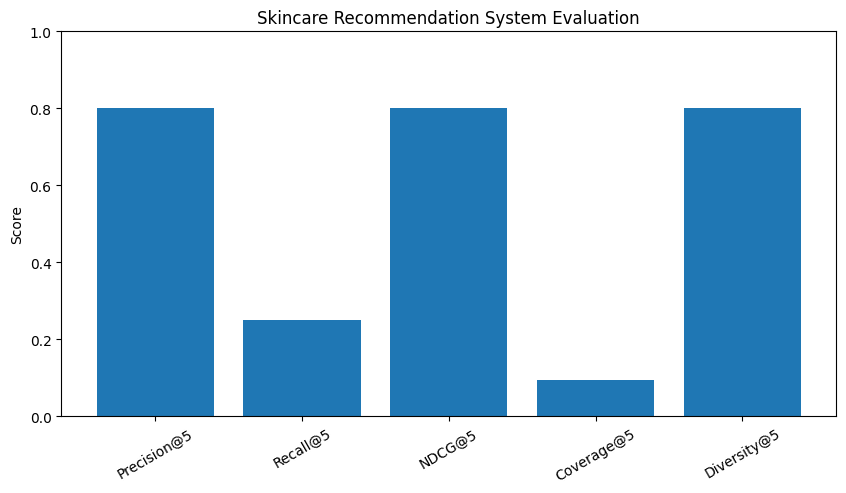

In [77]:
plt.figure(figsize=(10, 5))

metrics_to_plot = [
    "Precision@5",
    "Recall@5",
    "NDCG@5",
    "Coverage@5",
    "Diversity@5"
]

values = [
    final_evaluation[m]
    for m in metrics_to_plot
]

plt.bar(metrics_to_plot, values)

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("Skincare Recommendation System Evaluation")

plt.xticks(rotation=30)

plt.show()

# 23. Successful Test Cases

Inspect representative scenarios where recommendations should perform well.

In [66]:
success_cases = [
    {
        "name": "Oily skin + Acne",
        "skin_type": "Oily",
        "concerns": ["Acne"],
        "category": "All"
    },
    {
        "name": "Dry skin + Hydration",
        "skin_type": "Dry",
        "concerns": ["Hydration"],
        "category": "All"
    },
    {
        "name": "Combination skin + Dark Spots",
        "skin_type": "Combination",
        "concerns": ["Dark Spots"],
        "category": "All"
    }
]

for case in success_cases:
    
    print("=" * 60)
    print(case["name"])
    
    result = recommend_products(
        case["skin_type"],
        case["concerns"],
        case["category"],
        top_k=5
    )
    
    display(
        result[
            [
                "product",
                "skin_type_clean",
                "concerns_list",
                "category",
                "final_score"
            ]
        ]
    )

Oily skin + Acne


,product,skin_type_clean,concerns_list,category,final_score
24,Forest Essentials Delicate Facial Cleanser Kashmiri Saffron & Neem,Oily,[Acne],Cleanser,0.880977
17,Klm Klin Face Wash,Oily,[Acne],Cleanser,0.880977
61,Green Tea Pore Cleansing Complete Range Combo with AHA BHA PHA Peel,Oily,[Acne],Cleanser,0.880977
21,Aziclear Anti Acne Facial Cleanser,Oily,[Acne],Cleanser,0.880977
174,Hydew Moisturiser,Oily,[Acne],Moisturizer,0.877756


Dry skin + Hydration


,product,skin_type_clean,concerns_list,category,final_score
75,AirGel NMF-15% Moisturiser,Dry,[Hydration],Moisturizer,0.88813
110,Ponds Super Light Gel Oil Free Moisturiser With Hyaluronic Acid + Vitamin E,Dry,[Hydration],Moisturizer,0.88813
180,Rivona HA Aqua Moisturizing Cream with 2% Hyaluronic Acid and Cucumber Extracts,Dry,[Hydration],Moisturizer,0.88813
51,DOUSE BARRIER REPAIR FACE CREAM,Dry,[Hydration],Moisturizer,0.88813
10,Simple replenishing rich moisturiser,Dry,[Hydration],Moisturizer,0.88813


Combination skin + Dark Spots


,product,skin_type_clean,concerns_list,category,final_score
70,Melaglow Rich Cream,Combination,[Dark Spots],Moisturizer,0.889670
176,Conscious Chemist Pigmentation & Dark Spot Corrector Gel Cream,Combination,"[Dark Spots, Pigmentation]",Moisturizer,0.663935
136,Kozicare Skin Lightening Cream,Combination,"[Dark Spots, Pigmentation]",Moisturizer,0.663935
62,The Derma Co 2% Niacinamide Oily Skin Cleanser,Combination,"[Dark Spots, Pigmentation]",Cleanser,0.663882
69,Ethiglo Face Wash,Combination,"[Dark Spots, Pigmentation]",Cleanser,0.663882


# 24. Failure Scenarios & Limitations

Inspect cases where the catalog or available attributes constrain recommendation quality.

In [67]:
failure_cases = [
    {
        "name": "Rare combination",
        "skin_type": "Sensitive",
        "concerns": ["Anti-Aging", "Dark Spots"],
        "category": "All"
    },
    {
        "name": "Very specific category",
        "skin_type": "Oily",
        "concerns": ["Acne"],
        "category": "Eye Care"
    }
]

for case in failure_cases:
    
    print("=" * 60)
    print(case["name"])
    
    result = recommend_products(
        case["skin_type"],
        case["concerns"],
        case["category"],
        top_k=5
    )
    
    display(
        result[
            [
                "product",
                "skin_type_clean",
                "concerns_list",
                "category",
                "final_score"
            ]
        ]
    )

Rare combination


,product,skin_type_clean,concerns_list,category,final_score
182,Rivona Mineral Sunscreen with SPF 50+ UVA UVB PA+++,Sensitive,[Sun Protection],Sunscreen,0.428649
166,SensiSoothe Sunscreen SPF 50 PA++++ Mineral with Ceramides & Rice,Sensitive,[Sun Protection],Sunscreen,0.428649
78,Foxtale Acne Control Cleanser with Salicylic Acid,Sensitive,[Acne],Cleanser,0.428602
92,Mamaearth Anti-Pollution Daily Face Cream,Sensitive,[Acne],Moisturizer,0.427695
119,Pure Bubbles Niacinamide & Zinc PCA Facewash,Sensitive,[Acne],Other,0.426577


Very specific category


,product,skin_type_clean,concerns_list,category,final_score


# 25. Final Takeaways

- The recommender combines content similarity with explicit user-preference signals.
- Recommendations include human-readable explanations.
- Evaluation covers **Precision@5, Recall@5, NDCG@5, Coverage@5, Diversity@5, and latency**.
- The current solution addresses the **cold-start** case through explicit user preferences.
- With real click, wishlist, purchase, or rating data, the system could be extended into a hybrid collaborative + content-based recommender.